In [1]:
import nupack
import math
import matplotlib.pyplot as plt

# Secondary structure model specification

Specify a free energy model including:
- `parameters`: the parameter set description to use. If 'RNA' or 'DNA' are specified, the default parameter sets for those materials will be used. A full parameter file may be specified, for example, by `parameters=nupack.ParameterFile(material='RNA', dG='rna1995.dG', dH='rna1995.dH')`
- `T`: the temperature, in Kelvin (default=`310.15`)
- `mg`: the magnesium ion concentration $\text{Mg}^{2+}$, in moles per liter (default=`0.0`)
- `na`: the sodium ion concentration $\text{Na}^{+}$, in moles per liter (default=`1.0`)
- `gt`: whether wobble pairs (G$\cdot$U or G$\cdot$T) are allowed (default=`True`)
- `ensemble`: the recursions to use, from `['nostacking', 'stacking', 'none', 'min', 'all']` (default=`'stacking'`). Using `'nostacking'`, no dangle or stacking energies will be incorporated. Using `'min'`, a dangle energy is incorporated for each unpaired base flanking a duplex (a base flanking two duplexes contributes only the minimum of the two possible dangle energies). Using `'all'`, a dangle energy is incorporated for each base flanking a duplex regardless of whether it is paired. Using `'stacking'`, every possible coaxial stacking and dangle state is incorporated into the recursions.

In [2]:
model = nupack.Model(parameters='DNA', T=(23+273.15), mg=0, na=0.1, ensemble=nupack.Ensemble.stacking)

# Example 2: Partition function for a complex.
Calculate the partition function for a complex of four DNA strands at 23 ◦C, two of which are indistinguishable.

## Input file contents:

```
3
AGTCTAGGATTCGGCGTGGGTTAA 
TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
1223
```

## Command: 

```bash
pfunc -T 23 -multi -material dna $NUPACKHOME/doc/examples/complex-analysis/advanced/input/hcr
```

In [3]:
analysis = nupack.Analysis(model=model)

strands = (
    'AGTCTAGGATTCGGCGTGGGTTAA',
    'TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG',
    'TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG',
    'AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG'
)

analysis.partition_function(strands)
complex_result = analysis.compute()[strands]

print('Free energy = %.2f kcal/mol' % complex_result.free_energy)
print('Partition function = %.3e' % math.exp(complex_result.log_partition_function))

Free energy = -109.68 kcal/mol
Partition function = 8.775e+80


# Example 3: Test tube analysis. 

Calculate the partition function, equilibrium pair probabilities, MFE structure(s), and equilibrium concentration for each complex in a test tube containing three DNA strand species that interact to form all complex species of up to four strands, plus additional larger complexes specified in a .list file.

## Input file contents:

```
3
AGTCTAGGATTCGGCGTGGGTTAA
TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
4
```

## List file contents:

```
1 2 2 3 3
1 2 3 2 3
2 3 2 3 2
1 2 2 2 3 3
```

## Strand concentrations file contents:

```
1e-6
1.1e-6
0.9e-6
```

## Commands: 

```bash
complexes -T 23 -material dna -pairs -mfe -degenerate $NUPACKHOME/doc/examples/tube-analysis/advanced/input/hcr
concentrations -pairs $NUPACKHOME/doc/examples/tube-analysis/advanced/input/hcr
```

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 2]
    Concentration = 1.694e-07 M
    Complex free energy = -73.198 kcal/mol
    MFE = -71.524 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+........................))))))))))))))))))))))))


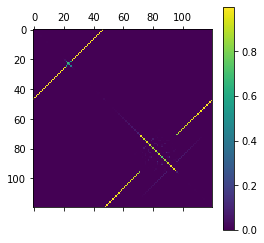

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 2, 1]
    Concentration = 1.461e-14 M
    Complex free energy = -63.625 kcal/mol
    MFE = -60.134 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.(((((((((((((((((......))))))))))))))))))).....+...)))))))))))))))))))))(..((....)).)...........


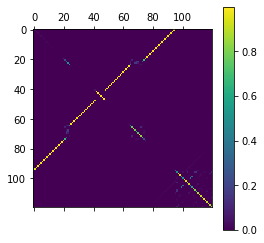

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 0, 2, 1]
    Concentration = 1.973e-15 M
    Complex free energy = -74.372 kcal/mol
    MFE = -69.942 kcal/mol
    MFE structure = ...........((.((........+(((((((((((((((((((((((.+.(((((((((((((((((......))))))))))))))))))).....+...)))))))))))))))))))))(..((....)).)....)).))..


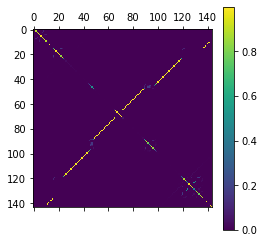

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 0, 2]
    Concentration = 1.527e-08 M
    Complex free energy = -83.706 kcal/mol
    MFE = -81.332 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+...........((.((........+...........)).))........))))))))))))))))))))))))


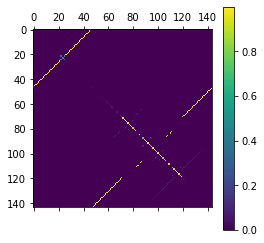

Complex = TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [1, 1]
    Concentration = 3.255e-16 M
    Complex free energy = -50.848 kcal/mol
    MFE = -49.081 kcal/mol
    MFE structure = ......((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


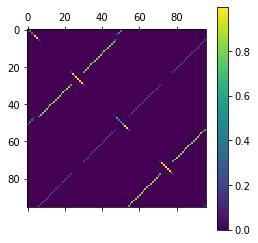

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 2, 1, 1]
    Concentration = 2.110e-24 M
    Complex free energy = -111.177 kcal/mol
    MFE = -107.719 kcal/mol
    MFE structure = ........................((((((((((((((((((((((((+((((((((((((((((((((((((((((((((((((((((((((((((+........................))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


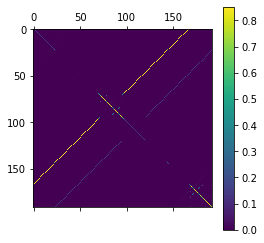

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 2, 1]
    Concentration = 5.418e-20 M
    Complex free energy = -80.257 kcal/mol
    MFE = -77.242 kcal/mol
    MFE structure = ((((((((((((((((((......))))))))))))))))........+((((((((((((((((((......)))))))))))))))))).))((.+..))..((((((((((((((((((......))))))))))))))))))


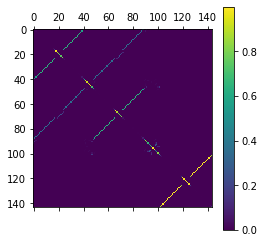

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 1, 2, 1]
    Concentration = 3.987e-27 M
    Complex free energy = -107.894 kcal/mol
    MFE = -103.463 kcal/mol
    MFE structure = ((((((((((((((((((......)))))))))))))))))).((((.+..))..((((((((((((((((((......))))))))))))))))))+))((((((((((((((((......)))))))))))))))).......(+.....)((((((((((((((((((......))))))))))))))))))


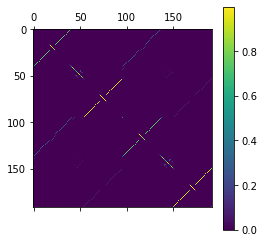

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 0, 0, 1]
    Concentration = 8.374e-12 M
    Complex free energy = -55.296 kcal/mol
    MFE = -51.069 kcal/mol
    MFE structure = ...........((.((........+...........)).))((......+((((((((((((((((((((((((+))))))))))))))))))))))))))......................


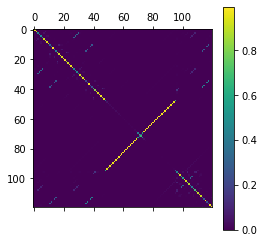

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA
    Strand indices = [0, 0, 0]
    Concentration = 3.710e-12 M
    Complex free energy = -18.569 kcal/mol
    MFE = -15.329 kcal/mol
    MFE structure = ...((((....((.((........+...........)).))........+...)))).................


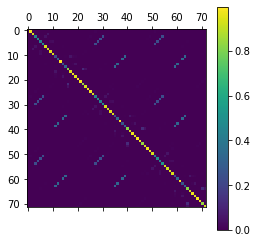

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 0, 1]
    Concentration = 1.041e-08 M
    Complex free energy = -47.565 kcal/mol
    MFE = -44.412 kcal/mol
    MFE structure = ...........((.((........+((((((((((((((((((((((((+))))))))))))))))))))))))(..((....)).)....)).))..


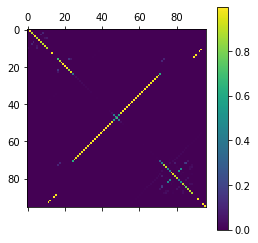

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA
    Strand indices = [0, 0, 0, 0]
    Concentration = 1.588e-13 M
    Complex free energy = -28.809 kcal/mol
    MFE = -24.967 kcal/mol
    MFE structure = ...((((....((.((........+...........)).))........+...))))....((.((........+...........)).))........


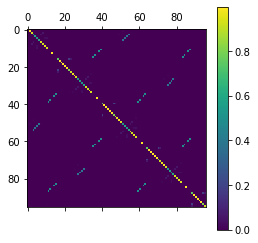

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [2]
    Concentration = 7.371e-08 M
    Complex free energy = -23.889 kcal/mol
    MFE = -23.255 kcal/mol
    MFE structure = ((((((((((((((((((......))))))))))))))))))......


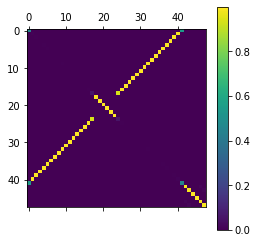

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 1, 1]
    Concentration = 8.434e-13 M
    Complex free energy = -66.991 kcal/mol
    MFE = -64.137 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))(......)....((..........+....))((((((((((((((((((......))))))))))))))))))


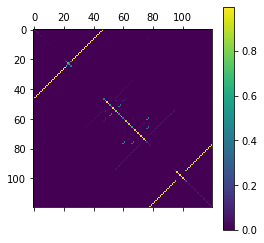

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 2, 2]
    Concentration = 1.782e-16 M
    Complex free energy = -60.053 kcal/mol
    MFE = -56.436 kcal/mol
    MFE structure = ((((((((((((((((((......+........................((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))......


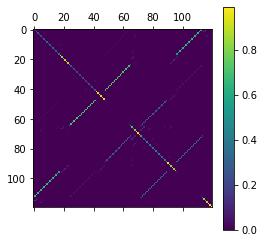

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 0, 2, 2]
    Concentration = 1.387e-17 M
    Complex free energy = -70.476 kcal/mol
    MFE = -66.244 kcal/mol
    MFE structure = ((((((((((((((((((......+...........((.((........+...........)).))........((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))......


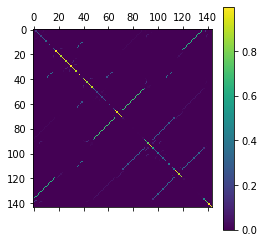

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 1, 0, 1]
    Concentration = 9.610e-10 M
    Complex free energy = -83.465 kcal/mol
    MFE = -78.608 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))(..((....)).)....((.((..+((((((((((((((((((((((((+))))))))))))))))))))))))(..((....)).)....)).))..


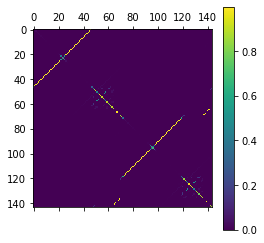

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 1]
    Concentration = 1.558e-14 M
    Complex free energy = -51.738 kcal/mol
    MFE = -49.884 kcal/mol
    MFE structure = ((((((((((((((((((......)))))))))))))))))).....(+.....)((((((((((((((((((......))))))))))))))))))


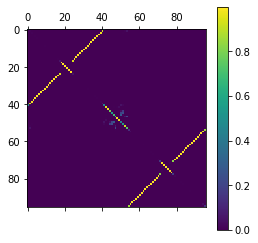

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 1, 1, 1]
    Concentration = 6.638e-28 M
    Complex free energy = -107.410 kcal/mol
    MFE = -102.695 kcal/mol
    MFE structure = .(((((((((((((((((......)))))))))))))))).......(+.....)((((((((((((((((((......))))))))))))))))))+.....)((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


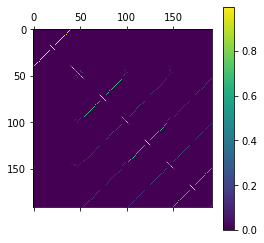

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 2, 2, 1]
    Concentration = 2.256e-25 M
    Complex free energy = -108.882 kcal/mol
    MFE = -104.082 kcal/mol
    MFE structure = ((((((((((((((((((......)))))))))))))))))).....(+((((((((((((((((((......)))))))))))))))))).....(+((((((((((((((((((......))))))))))))))))))...((.+..))))((((((((((((((((((......))))))))))))))))))


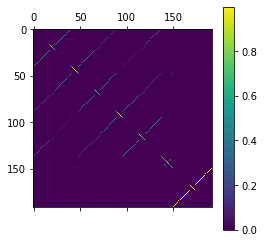

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 0, 0, 2]
    Concentration = 1.010e-15 M
    Complex free energy = -49.007 kcal/mol
    MFE = -44.193 kcal/mol
    MFE structure = ((((((((((((((((((......+...((((....((.((........+...........)).))........+...)))).................))))))))))))))))))......


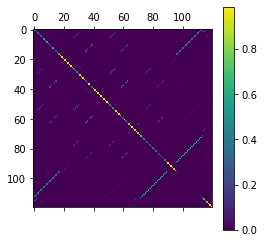

Complex = TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [1]
    Concentration = 6.807e-09 M
    Complex free energy = -23.465 kcal/mol
    MFE = -23.071 kcal/mol
    MFE structure = ......((((((((((((((((((......))))))))))))))))))


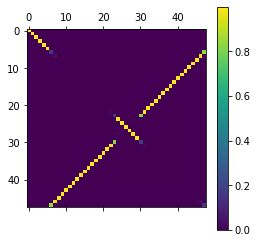

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 0, 1, 2]
    Concentration = 1.248e-12 M
    Complex free energy = -78.167 kcal/mol
    MFE = -75.055 kcal/mol
    MFE structure = ((((((((((((((((((((((((+..............(....)))))+....))))))))))))))))))))((((((((((((((((((((((((+........................))))))))))))))))))))))))


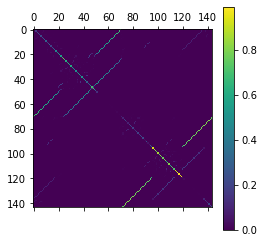

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [2, 2]
    Concentration = 4.138e-14 M
    Complex free energy = -51.742 kcal/mol
    MFE = -49.449 kcal/mol
    MFE structure = ((((((((((((((((((......((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))......


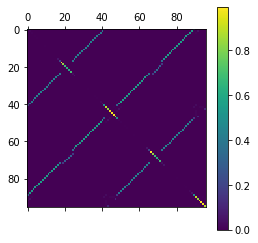

Complex = TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [1, 1, 1, 1]
    Concentration = 2.791e-30 M
    Complex free energy = -105.984 kcal/mol
    MFE = -100.849 kcal/mol
    MFE structure = ((((..((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))+))))..((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


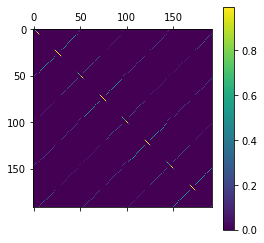

Complex = TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [1, 1, 1]
    Concentration = 2.184e-23 M
    Complex free energy = -78.261 kcal/mol
    MFE = -74.600 kcal/mol
    MFE structure = ((((..((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))+))))..((((((((((((((((((......))))))))))))))))))


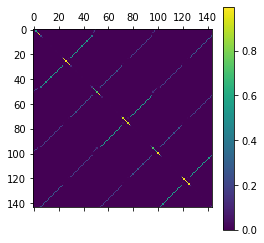

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [2, 2, 2, 2]
    Concentration = 1.856e-25 M
    Complex free energy = -108.605 kcal/mol
    MFE = -102.114 kcal/mol
    MFE structure = (((((((((((((((((..(((((((((((((((((((((((......+))))))))))))))))))..)))))(((((((((((((((((......+)))))))))))))))))..(((((((((((((((((((((((......+))))))))))))))))))..))))))))))))))))))))))......


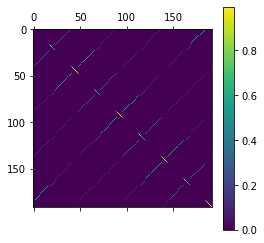

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 1, 1, 1]
    Concentration = 3.623e-18 M
    Complex free energy = -96.613 kcal/mol
    MFE = -93.368 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))(......)....((....((....+....))((((((((((((((((((......))))))))))))))))))+....))((((((((((((((((((......))))))))))))))))))


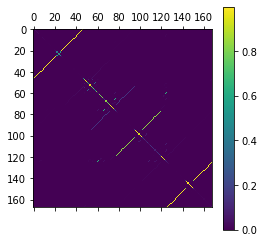

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 2, 2]
    Concentration = 7.075e-12 M
    Complex free energy = -103.180 kcal/mol
    MFE = -100.233 kcal/mol
    MFE structure = ((((((((((((((((((......+((((((((((((((((((((((((((((((((((((((((((((((((+........................))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))......


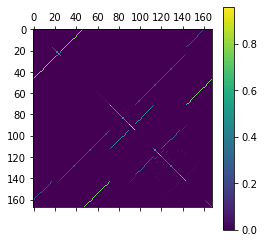

Complex = AGTCTAGGATTCGGCGTGGGTTAA
    Strand indices = [0]
    Concentration = 3.219e-07 M
    Complex free energy = -0.765 kcal/mol
    MFE = 0.000 kcal/mol
    MFE structure = ........................


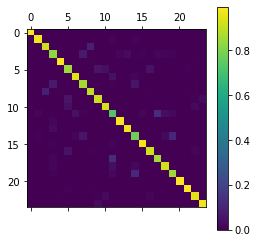

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 2, 1, 2]
    Concentration = 3.199e-14 M
    Complex free energy = -100.002 kcal/mol
    MFE = -97.054 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.(((((((((((((((((......))))))))))))))))))).....+...)))))))))))))))))))))((((((((((((((((((((((((+........................))))))))))))))))))))))))


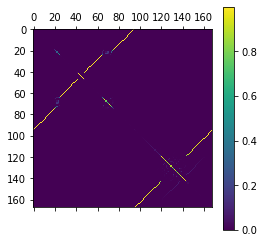

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 2]
    Concentration = 9.721e-12 M
    Complex free energy = -30.556 kcal/mol
    MFE = -28.218 kcal/mol
    MFE structure = ((((((((((((((((((......+........................))))))))))))))))))......


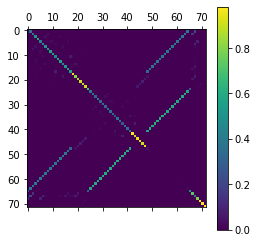

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 2, 2, 1]
    Concentration = 4.637e-20 M
    Complex free energy = -92.091 kcal/mol
    MFE = -87.512 kcal/mol
    MFE structure = ((((((((((((((((((((((((+((((((((((((((((((......))))))))))))))))........+((((((((((((((((((......)))))))))))))))))).)))).+..))))))))))))))))))))))(..((....)).)...........


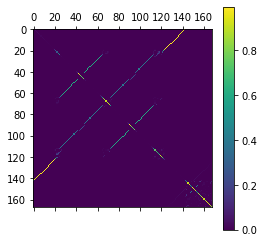

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 0, 1, 1]
    Concentration = 1.631e-13 M
    Complex free energy = -77.948 kcal/mol
    MFE = -74.387 kcal/mol
    MFE structure = ......((...((.((........+((((((((((((((((((((((((+))))))))))))))))))))))))(..((....)).)....)).))..+....))((((((((((((((((((......))))))))))))))))))


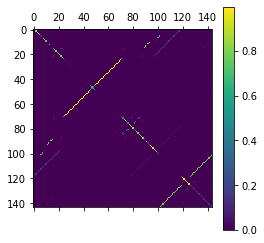

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 2, 0, 2]
    Concentration = 6.321e-18 M
    Complex free energy = -70.421 kcal/mol
    MFE = -65.836 kcal/mol
    MFE structure = ((((((((((((((((((......+...........((.((........((((((((((((((((((......+))))))))))))))))))......+...........)).))........))))))))))))))))))......


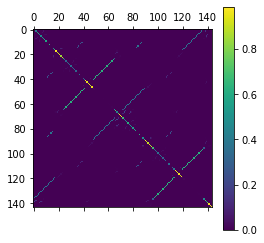

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 1, 1]
    Concentration = 3.184e-21 M
    Complex free energy = -79.568 kcal/mol
    MFE = -76.302 kcal/mol
    MFE structure = ((((((((((((((((((......)))))))))))))))))).....(+.....)((((((((((((((((((......((((((((((((((((((+......))))))))))))))))))......))))))))))))))))))


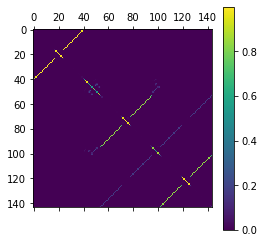

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [2, 2, 2]
    Concentration = 6.734e-20 M
    Complex free energy = -80.053 kcal/mol
    MFE = -75.655 kcal/mol
    MFE structure = ((((((((((((((((((......)))))))))))))))))).(((..+((((((((((((((((((......))))))))))))))))))).....+))((((((((((((((((......))))))))))))))))........


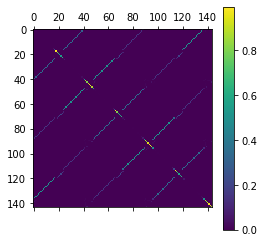

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA
    Strand indices = [0, 0]
    Concentration = 7.493e-09 M
    Complex free energy = -10.885 kcal/mol
    MFE = -9.400 kcal/mol
    MFE structure = ...........((.((........+...........)).))........


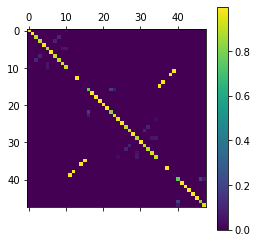

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 1, 2]
    Concentration = 8.462e-08 M
    Complex free energy = -109.684 kcal/mol
    MFE = -107.215 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+(((((((((((((((((((((((((..((....)).)...........+))))))))))))))))))))))))))))))))))))))))))))))))


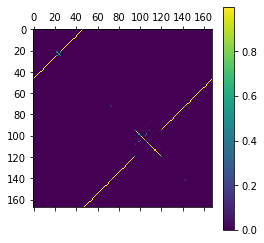

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 1, 2, 1]
    Concentration = 1.040e-15 M
    Complex free energy = -98.964 kcal/mol
    MFE = -96.225 kcal/mol
    MFE structure = .(((((((((((((((((((((((+)))))))))))))))))))))))(((((((((((((((((((((((((+........................))))))))))))))))))))))))+...)..((((((((((((((((((......))))))))))))))))))


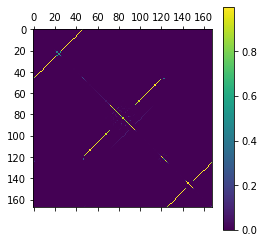

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 2, 1, 1]
    Concentration = 1.627e-19 M
    Complex free energy = -93.808 kcal/mol
    MFE = -89.667 kcal/mol
    MFE structure = (((((((((((((((((((((((.+.(((((((((((((((((......))))))))))))))))))).....+...)))))))))))))))))))))(......)....((..........+....))((((((((((((((((((......))))))))))))))))))


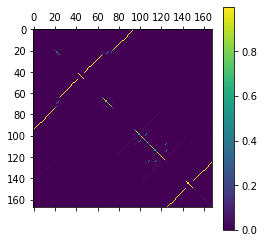

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 2, 2, 2]
    Concentration = 2.766e-21 M
    Complex free energy = -89.453 kcal/mol
    MFE = -84.654 kcal/mol
    MFE structure = ((((((((((((((((((......+........................((((((((((((((((((......+))))))))))))))))))......((((((((((((((((((......+))))))))))))))))))......))))))))))))))))))......


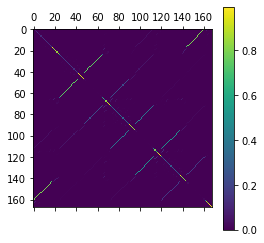

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [0, 1]
    Concentration = 7.721e-08 M
    Complex free energy = -36.819 kcal/mol
    MFE = -34.604 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))(..((....)).)...........


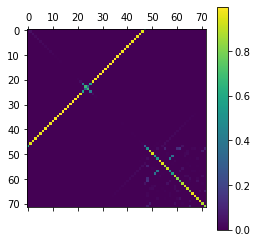

Complex = AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAA+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 0, 2]
    Concentration = 8.375e-13 M
    Complex free energy = -41.038 kcal/mol
    MFE = -38.026 kcal/mol
    MFE structure = ((((((((((((((((((......+...........((.((........+...........)).))........))))))))))))))))))......


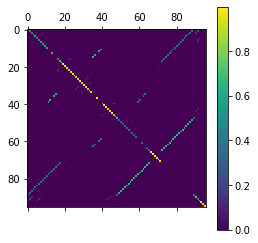

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 1, 2, 2]
    Concentration = 1.857e-07 M
    Complex free energy = -146.063 kcal/mol
    MFE = -144.135 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((((((((((((((((((((((((((((((((+........................))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


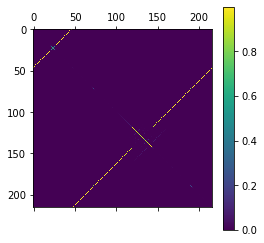

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 2, 1, 2]
    Concentration = 1.216e-14 M
    Complex free energy = -136.328 kcal/mol
    MFE = -131.745 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((......))))))))))))))))))...((.+..(((((((((((((((((((((((..((....)).)...........+))))))))))))))))))))))))))))))))))))))))))))))))


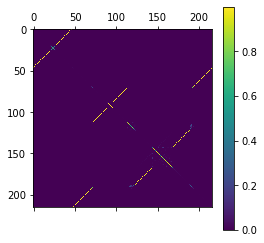

Complex = AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG
    Strand indices = [2, 1, 2, 1, 1]
    Concentration = 1.639e-32 M
    Complex free energy = -137.082 kcal/mol
    MFE = -132.420 kcal/mol
    MFE structure = ........................((((((((((((((((((((((((+...(..((((((((((((((((((......))))))))))))))))))+.(((((((((((((((((((((((((((((((((((((((((((((((+........................))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


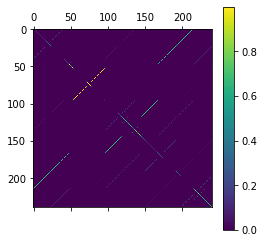

Complex = AGTCTAGGATTCGGCGTGGGTTAA+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG+AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG
    Strand indices = [0, 1, 1, 1, 2, 2]
    Concentration = 9.274e-08 M
    Complex free energy = -182.549 kcal/mol
    MFE = -179.827 kcal/mol
    MFE structure = ((((((((((((((((((((((((+))))))))))))))))))))))))((((((((((((((((((((((((+((((((((((((((((((((((((((((((((((((((((((((((((+(((((((((((((((((((((((((..((....)).)...........+))))))))))))))))))))))))))))))))))))))))))))))))+))))))))))))))))))))))))))))))))))))))))))))))))


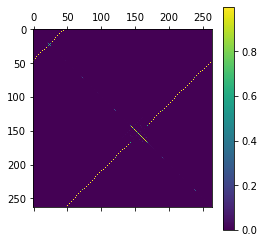

In [4]:
analysis = nupack.Analysis(model=model)

strands = (
    "AGTCTAGGATTCGGCGTGGGTTAA",
    "TTAACCCACGCCGAATCCTAGACTCAAAGTAGTCTAGGATTCGGCGTG",
    "AGTCTAGGATTCGGCGTGGGTTAACACGCCGAATCCTAGACTACTTTG",
)

analysis.pair_probability(strands, max_size=4)
analysis.min_free_energy(strands, max_size=4)

larger_complex_specs = [
    [1, 2, 2, 3, 3],
    [1, 2, 3, 2, 3],
    [2, 3, 2, 3, 2],
    [1, 2, 2, 2, 3, 3],
]

additional_complexes = [[strands[i-1] for i in x] for x in larger_complex_specs]

for cx in additional_complexes:
    analysis.pair_probability(cx)
    analysis.min_free_energy(cx)

complex_results = analysis.compute()

tube_solver = nupack.ConcentrationSolver(strands, complex_results)

strand_concentrations = [1e-6, 1.1e-6, 0.9e-6]

complex_concentrations = tube_solver.compute(strand_concentrations).complex_concentrations()

# tube = Tube(strands=strands, max_size=4, additional_complexes=additional_complexes)
# shows the sequences of the complexes in the tube
for cx, result in complex_concentrations.items():
    complex_result = complex_results[cx]
    print('Complex =', '+'.join(cx))
    print('    Strand indices =', [strands.index(strand) for strand in cx])
    print('    Concentration = %.3e M' % result)
    print('    Complex free energy = %.3f kcal/mol' % complex_result.free_energy)
    print('    MFE = %.3f kcal/mol' % complex_result.min_free_energy)
    print('    MFE structure = %s' % complex_result.suboptimal_structures[0][0])
    plt.matshow(complex_result.pair_probability, cmap='viridis')
    plt.colorbar()
    plt.grid(False)
    plt.show()    

# Example 4: 

Design a sequence for a complex of three DNA strands intended to adopt a target secondary structure at 23 ◦C. The first 24 nucleotides are constrained to nucleotide H (corresponding to a 3-letter alphabet) and the specified list of patterns are prevented throughout. A seed is set to make the design repeatable.

# Input file contents:

```
((((((((((((((((((((((((+((((((((((((((((((((((((.......................
.+))))))))))))))))))))))))))))))))))))))))))))))))
HHHHHHHHHHHHHHHHHHHHHHHH
```

# Prevent file contents:

```
AAAA
CCCC
GGGG
UUUU
KKKKKK
MMMMMM
RRRRRR
SSSSSS
WWWWWW
YYYYYY
```

# Seed file contents:

```
93
```

# Command: 

```bash
complexdesign -T 23 -material dna -pairs -loadseed -prevent $NUPACKHOME/doc/examples/complex-design/advanced/input/hcr-design.prevent $NUPACKHOME/doc/examples/complex-design/advanced/input/hcr-design
```

In [5]:
structure = "((((((((((((((((((((((((+((((((((((((((((((((((((........................+))))))))))))))))))))))))))))))))))))))))))))))))"
design = nupack.design.complex_design(structure)

design.model = nupack.design.ModelSettings(material="DNA", temperature=(23+273.15))
design.parameters.seed = 93

design.domains[0].allowed_bases = "HHHHHHHHHHHHHHHHHHHHHHHH"

patterns = ["AAAA", "CCCC", "GGGG", "UUUU", "KKKKKK", "MMMMMM", "RRRRRR", "SSSSSS", "WWWWWW", "YYYYYY"]
design.add_pattern_constraints(patterns)

print(design)
print("\n")
print(design())

Specification
    domains: [DomainSpec {name: domain 0, allowed_bases: HHHHHHHHHHHHHHHHHHHHHHHH}, DomainSpec {name: domain 0*, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: domain 1, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: domain 1*, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: domain 2, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: domain 2*, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}]
    strands: [StrandSpec {name: strand 0, domain_names: [domain 0]}, StrandSpec {name: strand 1, domain_names: [domain 1]}, StrandSpec {name: strand 2, domain_names: [domain 2]}]
    complexes: [ComplexSpec
            name: complex
            strands: [strand 0, strand 1, strand 2]
            structure: Structure("(24+(24.24+)48")]
    tubes: [TubeSpec {name: tube, targets: [([complex] : 1)]}]
    model: ModelKey {parameters: ParameterFile {path:

# Example 5: Test tube design. 

Design a sequence for a target test tube at default temperature 37 ◦C. The target test tube contains 1 on-target dimer (with a target structure and target concentration) and all off-target complexes of up to 2 strands (each with vanishing target concentration).

## Script file contents:

```python
# set properties
material = dna
seed = 93 # set seed to make design repeatable
# define target structure for 1 on-target complex
structure legs = ((((((((((((((((((((.......................+.......................))))))))))))))))))))
# define target test tube containing 1 on-target complex
tube walker = legs
# define target concentration for 1 on-target complex (molar)
# default: 1.0e-6
walker.legs.conc = 1.0e-6
# augment tube with all off-target complexes of up to 2 strands
# default: 0
walker.maxsize = 2
```

## Command: 

```bash
tubedesign $NUPACKHOME/doc/examples/tube-design/simple/input/walker-design
```

In [6]:
design = nupack.design.Design()
design.model = nupack.design.ModelSettings(material='DNA')

structure = '((((((((((((((((((((.......................+.......................))))))))))))))))))))'
lengths = [len(s) for s in structure.split('+')]

design.add_domain('left', 'N'*lengths[0])
design.add_domain('right', 'N'*lengths[1])

design.add_strand('sleft', ['left'])
design.add_strand('sright', ['right'])

design.add_complex("legs", ['sleft', 'sright'], structure=structure)

design.add_tube("walker", {"legs": 1e-6})
design.add_off_targets("walker", maxsize=2)

design.parameters.seed = 93

print(design)
print("\n")
print(design())

Specification
    domains: [DomainSpec {name: left, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: left*, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: right, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}, DomainSpec {name: right*, allowed_bases: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN}]
    strands: [StrandSpec {name: sleft, domain_names: [left]}, StrandSpec {name: sright, domain_names: [right]}]
    complexes: [ComplexSpec {name: legs, strands: [sleft, sright], structure: Structure("(20.23+.23)20")}, ComplexSpec {name: , strands: [sleft], structure: Structure("")}, ComplexSpec {name: , strands: [sleft, sleft], structure: Structure("")}, ComplexSpec {name: , strands: [sright], structure: Structure("")}, ComplexSpec {name: , strands: [sright, sright], structure: Structure("")}]
    tubes: [TubeSpec {name: walker, targets: [([legs] : 1e-06), ([sleft] : 0), ([sleft, sleft] : 0), ([sright] : 0), ([sright, s

# Example 6: Test tube ensemble defect. 

Calculate the test tube ensemble defect for a specified set of sequences and target test tube at default temperature 37 ◦C. The target test tube contains 1 on-target dimer (with a target structure and target concentration) and all off-target complexes of up to 2 strands (each with vanishing target concentration).

## Script file contents:

```python
# set properties
material = dna
# define 2 sequence domains
domain a = CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA
domain b = TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG
# define 2 strands
strand leg1 = a
strand leg2 = b
# define target structure for 1 on-target complex
structure legs = ((((((((((((((((((((.......................+.......................))))))))))))))))))))
# define strand ordering for 1 on-target complex
legs.seq = leg1 leg2
# define target test tube containing 1 on-target complex
tube walker = legs
# define target concentration for 1 on-target complex (molar)
# default:  1.0e-6
walker.legs.conc = 1.0e-6
# augment tube with all off-target complexes of up to 2 strands
# default:  0
walker.maxsize = 2
```

## Command: 

```bash
tubedefect $NUPACKHOME/doc/examples/tube-design/simple/input/walker-defect
```

In [7]:
design = nupack.design.Design()
design.model = nupack.design.ModelSettings(material='DNA')

design.add_domain('a', 'CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA')
design.add_domain('b', 'TTCCCTCTATATTTCTACACTCCCGACCACGCCGATGTTCACG')

design.add_strand('leg1', ['a'])
design.add_strand('leg2', ['b'])
structure = '((((((((((((((((((((.......................+.......................))))))))))))))))))))'

design.add_complex('legs', ['leg1', 'leg2'], structure=structure)
design.add_tube('walker', {'legs': 1e-6})
design.add_off_targets('walker', maxsize=2)

print(design.evaluate())

DesignResult
    model: ModelKey {parameters: ParameterFile {path: dna04.json}, ensemble: stacking, conditions: ModelConditions {temperature: 310.15, na_molarity: 1, mg_molarity: 0}}
    parameters: DesignParameters {rng_seed: 4060205947, f_stop: 0.02, f_passive: 0.01, H_split: 2, N_split: 12, f_split: 0.99, f_stringent: 0.99, dG_clamp: -20, M_bad: 300, M_reseed: 50, M_reopt: 3, f_redecomp: 0.03, f_refocus: 0.03, cache_bytes_of_RAM: 0, min_ppair: 1e-05, slowdown: 0, log: , decomposition_log: , thermo_log: , time_analysis: 1}
    stats: DesignStats {num_leaf_evaluations: 0, num_reseeds: 0, num_redecompositions: [], offtargets_added_per_refocus: [], design_time: 0, analysis_time: 0.0478999, final_Psi: EnsemblePartition {mask: [], deflate: 2.76677e-322}}
    objectives: [Objective {variant: MultitubeObjective()}]
    results: [SingleResult
            domains: {(a : CGTGAACATCGGCGTGGTCGACCAACCCCACACAAAAAACCTA), (a* : TAGGTTTTTTGTGTGGGGTTGGTCGACCACGCCGATGTTCACG), (b : TTCCCTCTATATTTCTACACT